## Analyse des métriques RAGAS

Objectif: visualiser les métriques présentes dans le CSV (`ragas_details_*.csv`).

Rappel:
- `faithfulness` = fidélité de la réponse au contexte récupéré
- `answer_relevancy` = pertinence de la réponse vis-à-vis de la question
- `context_precision` = qualité des contextes récupérés (bruit vs utile)
- `context_recall` = couverture des informations nécessaires (uniquement avec vraie ground truth)


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Charge automatiquement le dernier fichier ragas_details_*.csv
csv_candidates = sorted(Path('outputs/evaluations').glob('ragas_details_*.csv'))
if not csv_candidates:
    raise FileNotFoundError("Aucun fichier ragas_details_*.csv trouvé dans outputs/evaluations")

csv_path = csv_candidates[-1]
df = pd.read_csv(csv_path)
print(f"CSV chargé: {csv_path}")
print(f"Shape: {df.shape}")
print("Colonnes:", list(df.columns))

candidate_metrics = ['answer_relevancy', 'faithfulness', 'context_precision', 'context_recall']
metrics = [m for m in candidate_metrics if m in df.columns]
if not metrics:
    raise ValueError("Aucune colonne métrique RAGAS trouvée dans le CSV")

print("Métriques disponibles:", metrics)
df.head()


CSV chargé: outputs/evaluations/ragas_details_20260312_211745.csv
Shape: (10, 9)
Colonnes: ['id', 'category', 'user_input', 'retrieved_contexts', 'response', 'reference', 'answer_relevancy', 'faithfulness', 'context_precision']
Métriques disponibles: ['answer_relevancy', 'faithfulness', 'context_precision']


,id,category,user_input,retrieved_contexts,response,reference,answer_relevancy,faithfulness,context_precision
0,q1,simple,Quel est le nom complet de l'equipe codee OKC ?,"[""Code Nom complet de l'équipe 0 ATL Atlanta H...",Oklahoma City Thunder,OKC correspond a Oklahoma City Thunder.,0.769372,1.0,0.833333
1,q2,simple,"Selon le tableau des equipes, combien de point...","[""4 Code Nom complet de l'équipe Nombre de jou...","Selon le contexte fourni, OKC a un total de 98...",OKC totalise 9880 points.,0.840836,1.0,1.000000
2,q3,complex,"Parmi MIA, OKC, LAC et BKN, quelle equipe a le...","[""4 Code Nom complet de l'équipe Nombre de jou...",OKC Oklahoma City Thunder avec 9880 points tot...,"Parmi ces quatre equipes, OKC est premier avec...",0.755008,1.0,1.000000
3,q4,complex,Quelle est la difference de points totaux entr...,"[""4 Code Nom complet de l'équipe Nombre de jou...",La différence de points totaux entre OKC (9880...,La difference est de 52 points.,0.967023,1.0,1.000000
4,q5,simple,Combien de joueurs compte l'equipe Brooklyn Ne...,"[""Code Nom complet de l'équipe 0 ATL Atlanta H...",L'équipe Brooklyn Nets (BKN) compte 20 joueurs.,BKN compte 20 joueurs.,0.938674,1.0,0.500000


,na_ratio,non_null_count
answer_relevancy,0.0,10
faithfulness,0.0,10
context_precision,0.0,10


,count,mean,std,min,25%,50%,75%,max
answer_relevancy,10.0,0.837826,0.129903,0.638037,0.758599,0.885825,0.93966,0.967023
faithfulness,10.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000
context_precision,10.0,0.803333,0.294581,0.200000,0.583333,1.000000,1.00000,1.000000


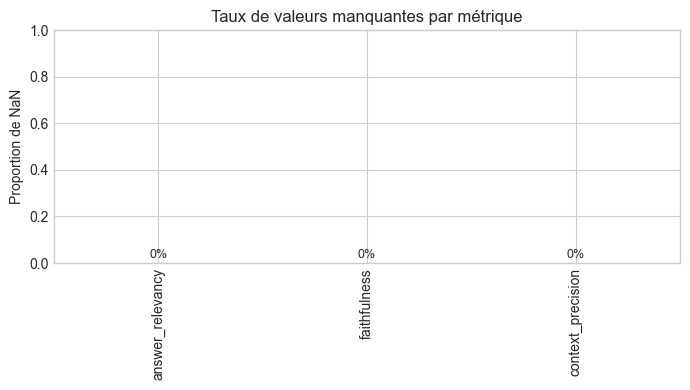

In [2]:
# 1) Diagnostic qualité: valeurs manquantes + stats descriptives
na_ratio = df[metrics].isna().mean().sort_values(ascending=False)
display(pd.DataFrame({'na_ratio': na_ratio, 'non_null_count': df[metrics].notna().sum()}))
display(df[metrics].describe().T)

ax = na_ratio.plot(kind='bar', color='#D55E00', figsize=(7, 4), ylim=(0, 1))
ax.set_title("Taux de valeurs manquantes par métrique")
ax.set_ylabel("Proportion de NaN")
for i, v in enumerate(na_ratio.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


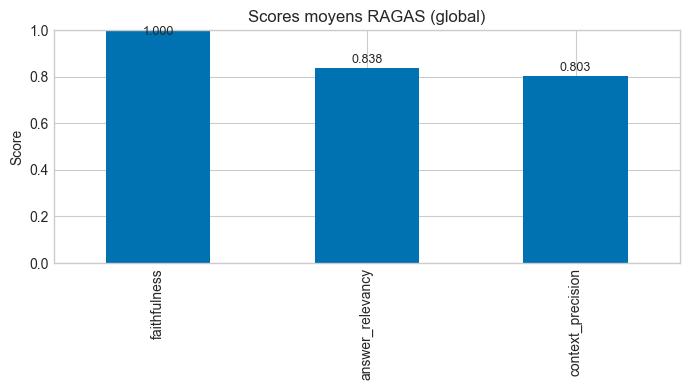

In [3]:
# 2) Score moyen global par métrique
mean_scores = df[metrics].mean().sort_values(ascending=False)

ax = mean_scores.plot(kind='bar', color='#0072B2', figsize=(7, 4), ylim=(0, 1))
ax.set_title("Scores moyens RAGAS (global)")
ax.set_ylabel("Score")
for i, v in enumerate(mean_scores.values):
    ax.text(i, min(v + 0.02, 0.98), f"{v:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


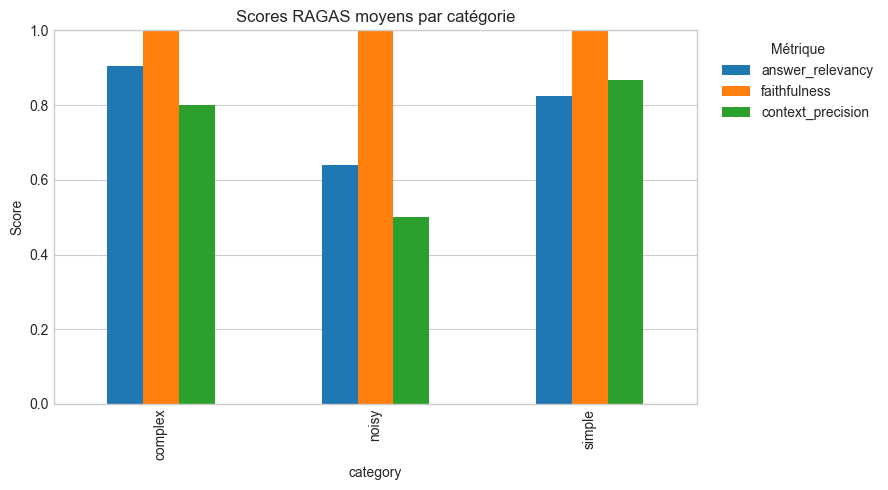

,answer_relevancy,faithfulness,context_precision
category,,,
complex,0.905428,1.0,0.800000
noisy,0.638813,1.0,0.500000
simple,0.823546,1.0,0.866667


In [4]:
# 3) Comparaison par catégorie de question
if 'category' in df.columns:
    by_cat = df.groupby('category', dropna=False)[metrics].mean().sort_index()
    ax = by_cat.plot(kind='bar', figsize=(9, 5), ylim=(0, 1))
    ax.set_title("Scores RAGAS moyens par catégorie")
    ax.set_ylabel("Score")
    ax.legend(title='Métrique', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    display(by_cat)
else:
    print("Colonne 'category' absente: visualisation par catégorie ignorée.")


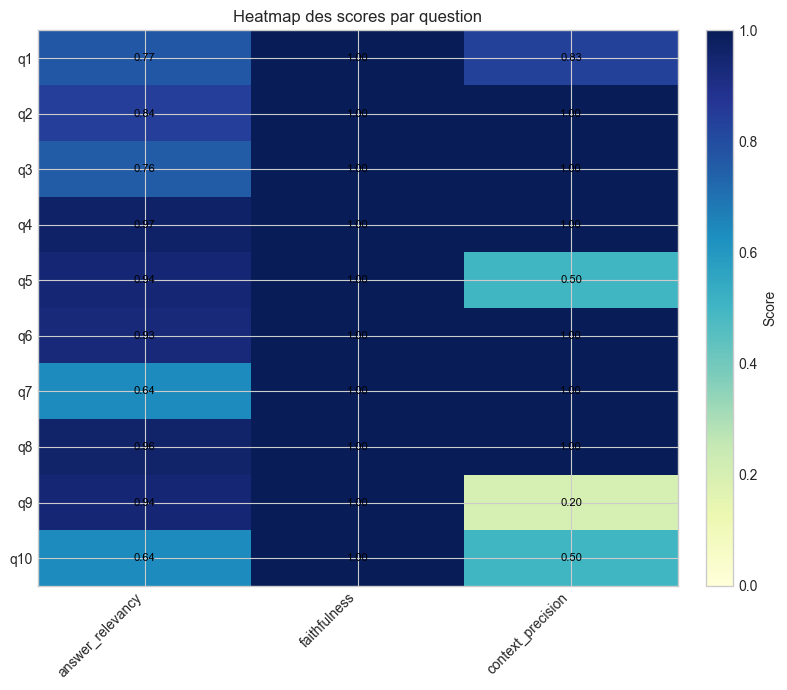

,answer_relevancy,faithfulness,context_precision
id,,,
q1,0.769372,1.0,0.833333
q2,0.840836,1.0,1.000000
q3,0.755008,1.0,1.000000
q4,0.967023,1.0,1.000000
q5,0.938674,1.0,0.500000
q6,0.930813,1.0,1.000000
q7,0.638037,1.0,1.000000
q8,0.959691,1.0,1.000000
q9,0.939989,1.0,0.200000


In [5]:
# 4) Heatmap question x métrique (utile pour repérer les cas faibles)
id_col = 'id' if 'id' in df.columns else None
base_cols = [c for c in [id_col, 'category', 'user_input'] if c and c in df.columns]
heat_df = df[base_cols + metrics].copy()

if id_col is None:
    heat_df.insert(0, 'id', [f'q{i+1}' for i in range(len(heat_df))])

heat_df = heat_df.set_index('id')
matrix = heat_df[metrics].fillna(0.0).values

fig, ax = plt.subplots(figsize=(8, max(3, 0.7 * len(heat_df))))
im = ax.imshow(matrix, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.set_yticks(range(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)
ax.set_title("Heatmap des scores par question")

for r in range(matrix.shape[0]):
    for c in range(matrix.shape[1]):
        ax.text(c, r, f"{matrix[r, c]:.2f}", ha='center', va='center', fontsize=8, color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Score')
plt.tight_layout()
plt.show()

display(heat_df[metrics])


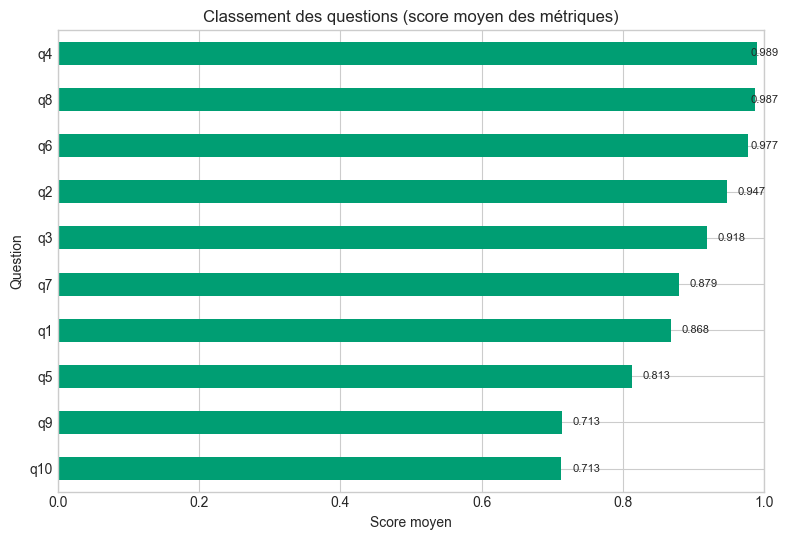

,id,category,score_moyen
3,q4,complex,0.989008
7,q8,complex,0.986564
5,q6,simple,0.976938
1,q2,simple,0.946945
2,q3,complex,0.918336
6,q7,simple,0.879346
0,q1,simple,0.867568
4,q5,simple,0.812891
8,q9,complex,0.713330
9,q10,noisy,0.712938


In [6]:
# 5) Score agrégé par question (moyenne des métriques disponibles)
score_col = 'score_moyen'
rank_df = df.copy()
rank_df[score_col] = rank_df[metrics].mean(axis=1, skipna=True)

label_col = rank_df['id'].astype(str) if 'id' in rank_df.columns else rank_df.index.astype(str)
plot_df = rank_df[[score_col]].copy()
plot_df['label'] = label_col
plot_df = plot_df.sort_values(score_col, ascending=True)

ax = plot_df.plot(kind='barh', x='label', y=score_col, legend=False, figsize=(8, max(3, 0.55 * len(plot_df))), xlim=(0, 1), color='#009E73')
ax.set_title("Classement des questions (score moyen des métriques)")
ax.set_xlabel("Score moyen")
ax.set_ylabel("Question")
for i, v in enumerate(plot_df[score_col].values):
    ax.text(min(v + 0.015, 0.98), i, f"{v:.3f}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

display(rank_df[['id', 'category', score_col]].sort_values(score_col, ascending=False) if {'id','category'}.issubset(rank_df.columns) else rank_df[[score_col]].sort_values(score_col, ascending=False))


faire un dummy pour avoir un élément de comparaison

audit méthodologique mise en avant -> démarche de recherche

biais identifié